In [ ]:
# time series component!

In [ ]:
import pandas as pd
from statsmodels.tsa.stattools import adfuller

maybe could be important understand more deeply what means ARIMA

ARIMA has three parameters:
* p
* d
* q
denoted as ARIMA(p,d,q)

p is the **order** of autoregressive ( how many lags affect the current value) (AR) terms.

d number of differences

q moving avarage (MA) terms


differencing is used to remove trend or non-stationary in the series.

d =0, no differencing d=1 one differencing.

# important things!

a trend is deterministic:
$$ y = \alpha t + e_{t}$$  the mean change with time a predictable way.

in this way first differencing eliminates the trend.

a **unit root** means the series is non-stationary due stochastic accumulation!! not deterministic trend!
example random walk:

$$ y_{t} = y_{t-1} + e_{t} $$ here the mean depends on past values!! first differencing remove unit root. both cause non-stationarity but by different ways.

a series with unit root may look like it has a trend. both can be removed differencing! but the causes are different.

# AR and MA

## AR dependence in past values
## MA dependece in past errors




important understand the different between boths!


AR is memory of serie, MA is memory of shocks!




Moving avarage, the current value of the serie depends on past random shocks!


Ok when you arrive again ask for MA and detailed explanation of what means!

ARIMA HAVE THREE PARAMTERS,
ARIMA(p,d,q)
p (Autoregressive)
how much the past affect the in the current value,
with **PACF ** could be seen p  =0 not uses lag..
p = 1 uses yesterday values.

d (Integrated - differentiation)
d = 0 already stationary..
d = 1 first order differentiation...


q Moving Avarage  (MA)
how many past errores determine the current value,
see the**ACF**.
q = 0  not use past errors..


q = 1  uses the previous error

ARIMA(0, 0, 1)


In [ ]:
import pandas as pd

url = "https://raw.githubusercontent.com/4GeeksAcademy/alternative-time-series-project/main/sales.csv"
df = pd.read_csv(url)
df['date'] = pd.to_datetime(df['date'])
df = df.set_index('date')
df = df.sort_index()

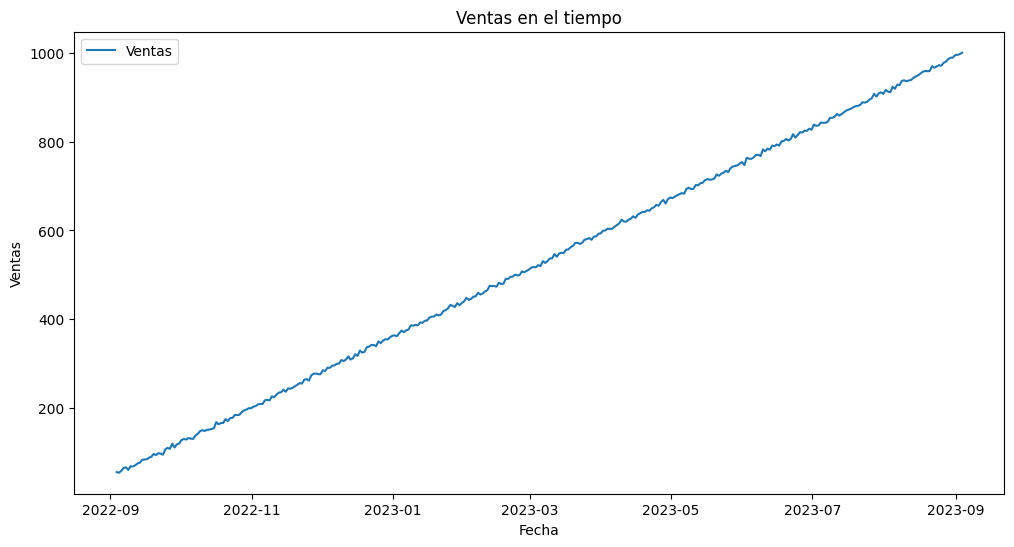

In [ ]:
import matplotlib.pyplot as plt
plt.figure(figsize=(12,6))
plt.plot(df.index, df['sales'], label="Ventas")
plt.title("Ventas en el tiempo")
plt.xlabel("Fecha")
plt.ylabel("Ventas")
plt.legend()
plt.show()

In [ ]:
adfuller(df['sales'])[1] # remember null hypothesis (no stationary!)

np.float64(0.9861899815311063)

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller


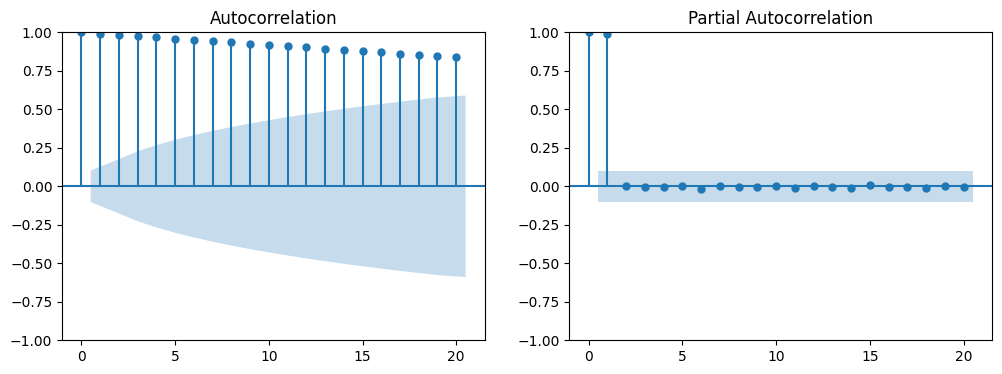

In [ ]:
# =========================
fig, axes = plt.subplots(1,2, figsize=(12,4))
plot_acf(df, ax=axes[0], lags=20)
plot_pacf(df, ax=axes[1], lags=20, method='ywm')
plt.show()

In [ ]:
# Ejemplo con parámetros p=1, d=1, q=1 (puedes ajustarlos)
# p se determina con el partial auto el grafico derecho
# q con autocor el grafico izquierdo
p, d, q = 1, 1, 2
modelo = ARIMA(df, order=(p,d,q))
modelo_fit = modelo.fit()

print("\n--- Resumen del modelo ---")
print(modelo_fit.summary())

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)



--- Resumen del modelo ---
                               SARIMAX Results                                
Dep. Variable:                  sales   No. Observations:                  366
Model:                 ARIMA(1, 1, 2)   Log Likelihood                -923.597
Date:                Tue, 10 Feb 2026   AIC                           1855.195
Time:                        02:47:41   BIC                           1870.794
Sample:                    09-03-2022   HQIC                          1861.394
                         - 09-03-2023                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          1.0000    2.5e-06      4e+05      0.000       1.000       1.000
ma.L1         -1.9353      0.023    -83.451      0.000      -1.981      -1.890
ma.L2          0.9358   